# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [17]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset


In [18]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")

## EDA
Uncomment to see desired output. Add more analysis if you like

Dataset shape: (4269, 13)
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')
   loan_id  no_of_dependents     education self_employed  income_annum  \
0        1                 2      Graduate            No       9600000   
1        2                 0  Not Graduate           Yes       4100000   
2        3                 3      Graduate            No       9100000   
3        4                 3      Graduate            No       8200000   
4        5                 5  Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506      

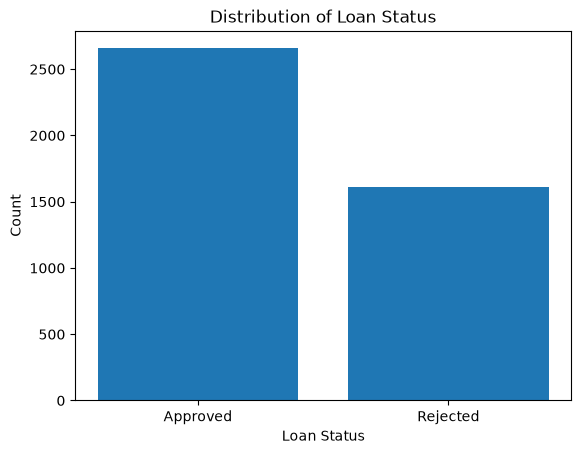

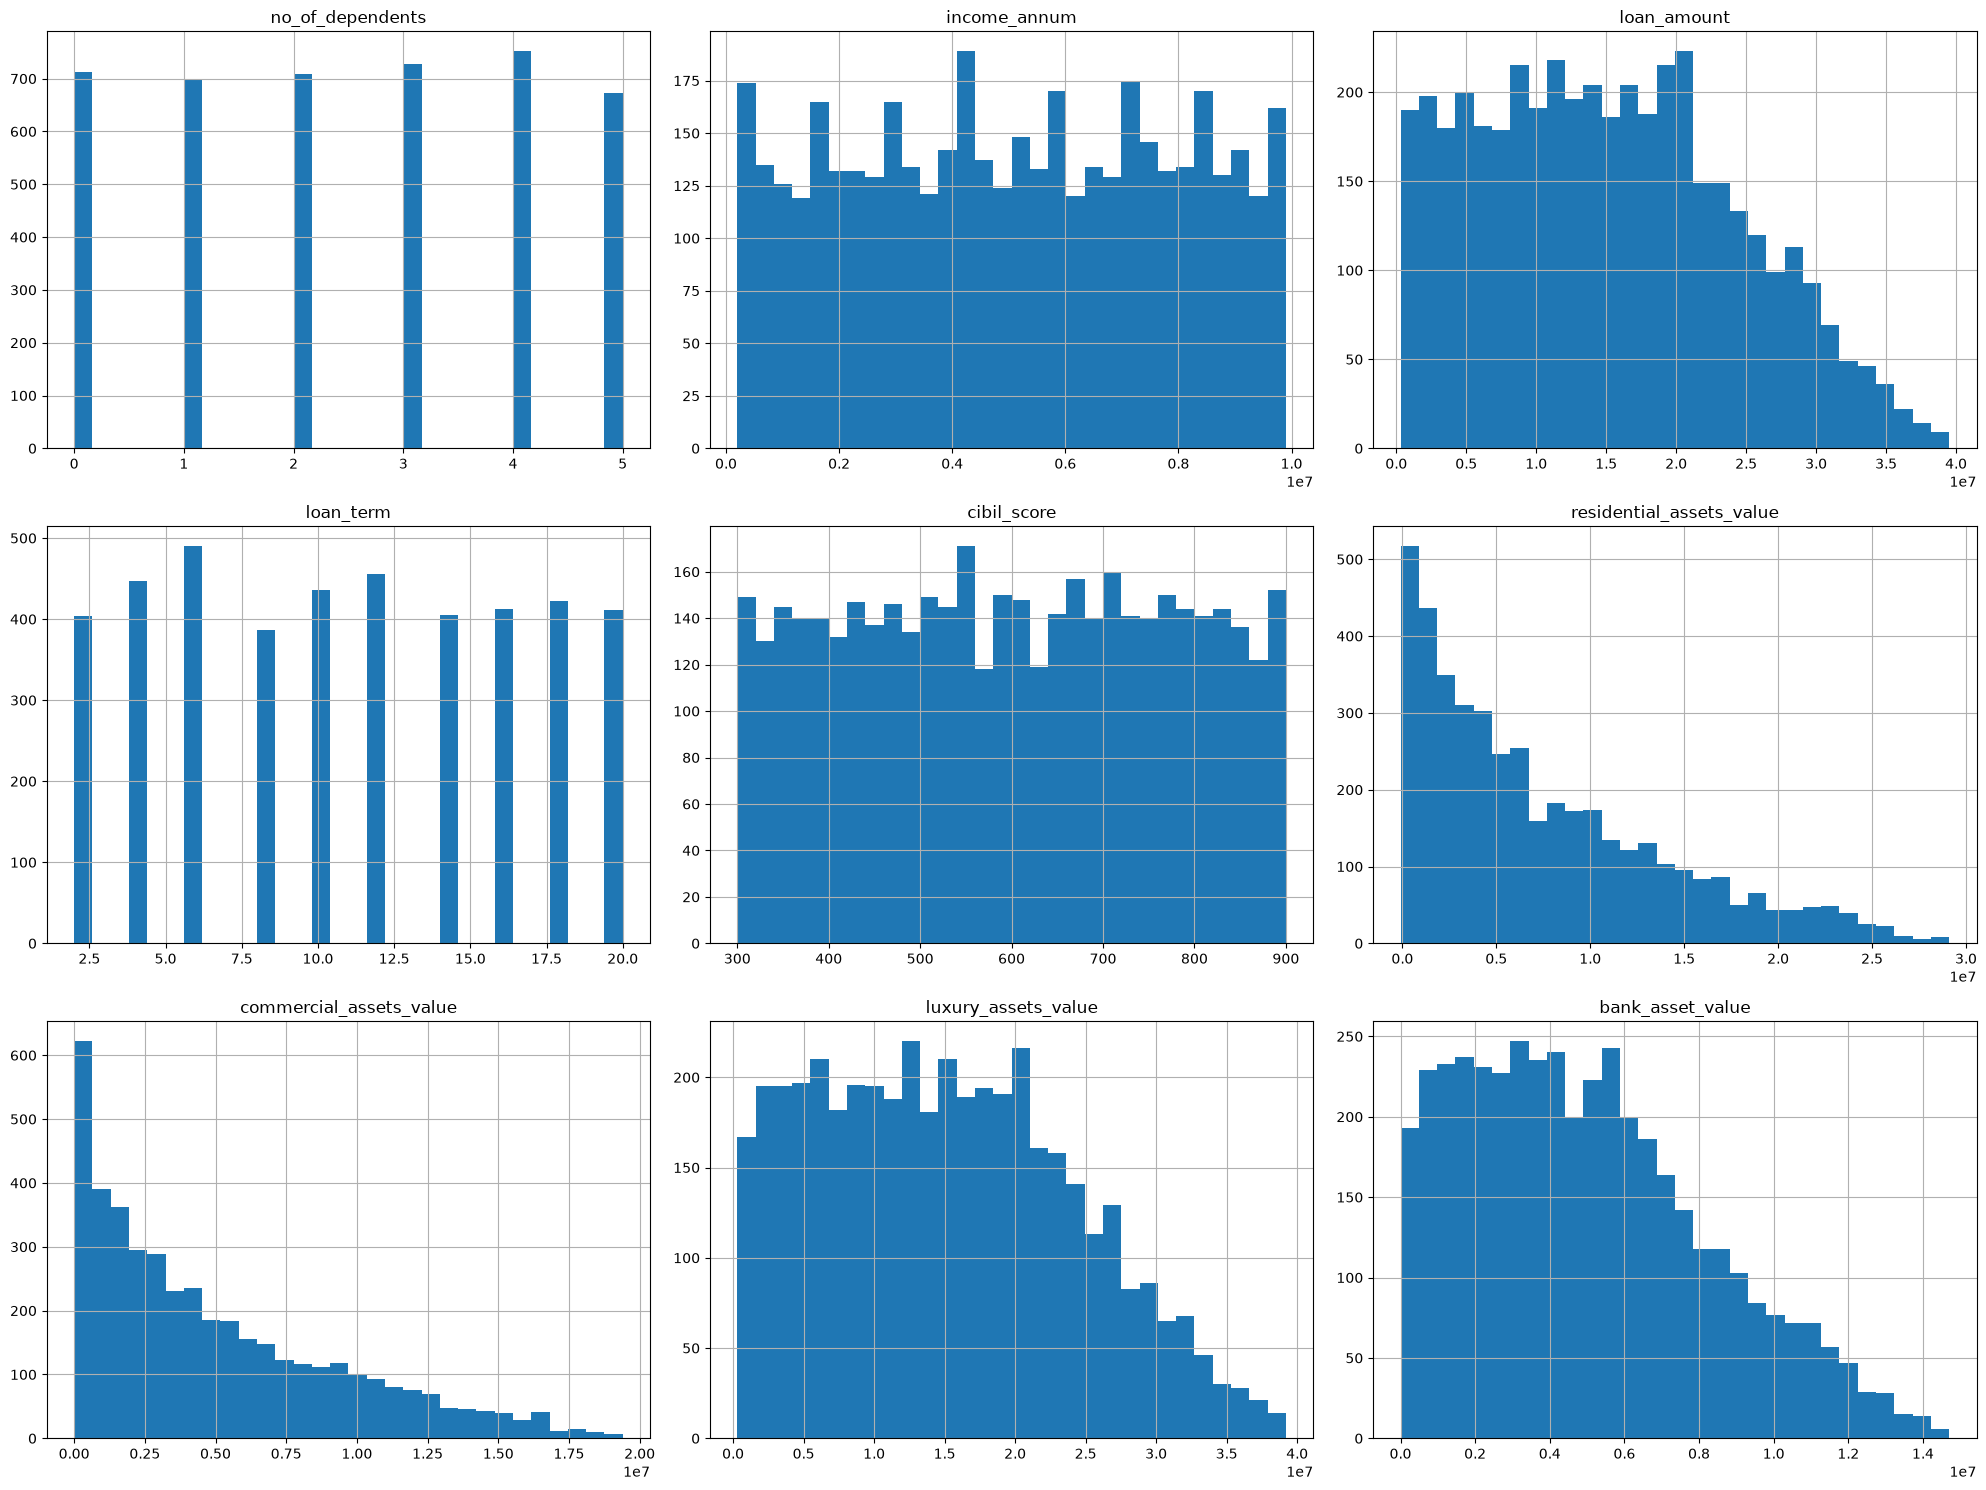

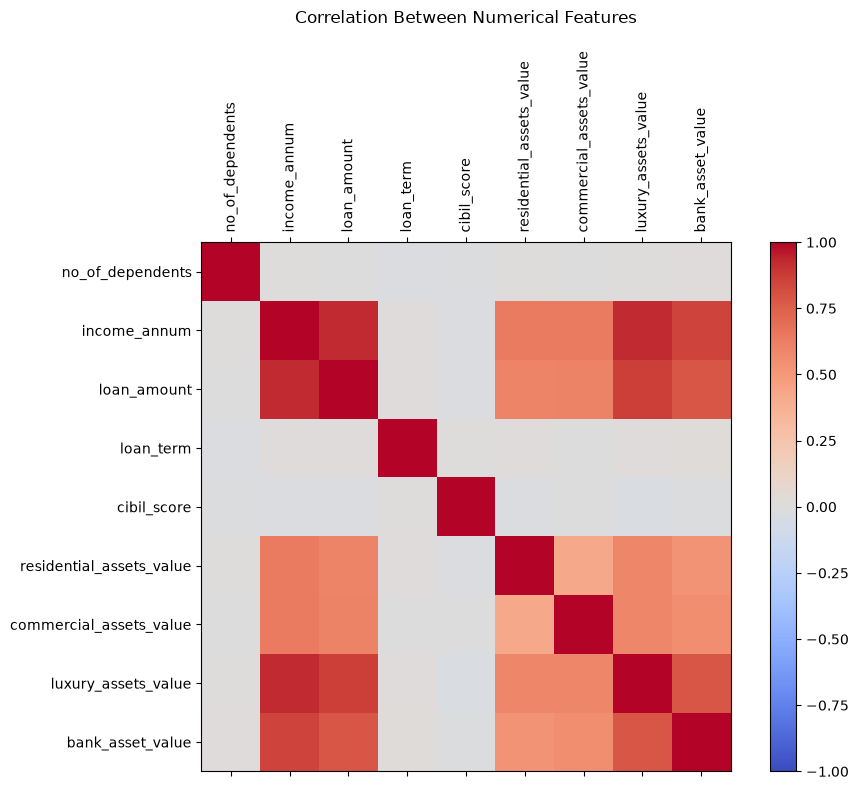

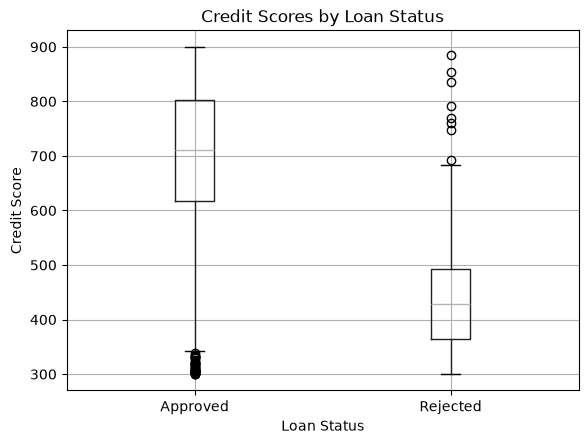

Average credit score by loan status:
loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64
Zero or negative incomes: 0
Negative residential asset values: 28


In [19]:
import matplotlib.pyplot as plt

# ------ Display basic information ------
print("Dataset shape:", loan_data.shape)
print(loan_data.columns)
print(loan_data.head())
print(loan_data.describe())

# ------ Check for missing values ------
print("Missing values:")
print(loan_data.isna().sum())
print("Duplicate rows:", loan_data.duplicated().sum())

# ------ Visualize the distribution of loan status ------
loan_status_counts = loan_data["loan_status"].value_counts()
print(loan_status_counts)

plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# ------ Visualize the distribution of numerical features ------
# Exclude loan_id because it identifies applications, not a measurement.
loan_data.drop(columns=["loan_id"]).hist(bins=30, figsize=(20, 15))
plt.tight_layout()
plt.show()

# ------ Correlation matrix ------
# Only include numerical columns and exclude the application ID.
corr_matrix = loan_data.drop(columns=["loan_id"]).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)
plt.title("Correlation Between Numerical Features", pad=20)
plt.tight_layout()
plt.show()

# ----- MORE (Encouraged but not required) ------
# Compare credit score distributions for approved and rejected loans.
loan_data.boxplot(column="cibil_score", by="loan_status")
plt.title("Credit Scores by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.show()

# Compare average credit scores for the two outcomes.
print("Average credit score by loan status:")
print(loan_data.groupby("loan_status")["cibil_score"].mean())

# Check for values that might need further investigation.
print("Zero or negative incomes:",
      (loan_data["income_annum"] <= 0).sum())

print("Negative residential asset values:",
      (loan_data["residential_assets_value"] < 0).sum())

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [20]:
# Convert categorical values into numbers.
loan_data["education"] = loan_data["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

loan_data["self_employed"] = loan_data["self_employed"].map({
    "Yes": 1,
    "No": 0
})

loan_data["loan_status"] = loan_data["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

# Compare the requested loan with the applicant's annual income.
loan_data["loan_to_income"] = (
    loan_data["loan_amount"] / loan_data["income_annum"]
)

loan_data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388


I changed the text categories into numbers so that the model can use them.I also created a ratio that represents loan:income to show how large each loan is compared with the applicantâ€™s annual income. All incomes in this dataset are positive, so this calculation doesn't divide by zero. This ratio measures loan size relative to income; it does not calculate monthly repayments.

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [21]:
# Use the application information to predict loan status.
# Remove loan_id because it's an identifier.
# Remove loan_status because it is like the answer we want to predict.
X = loan_data.drop(columns=["loan_id", "loan_status"])
y = loan_data["loan_status"]

# Start with a small decision tree.
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

The issue being addressed here involves classification since there will be two potential outcomes for each application, acceptance, or rejection. For the reason that decision trees build models using decision rules from asking questions about the attributes, they tend to provide clear insights that could be easily interpreted. Limiting the depth to three prevents overfitting. In addition, decision trees do not necessarily standardize numerical predictors.

## Model Training and Evaluation

In [22]:
# Set aside 20% of the data for final testing.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
###
# Split the remaining data into training and validation sets, giving 60% training, 20% validation, and 20% testing.

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

# Train the initial model.
model.fit(X_train, y_train)

# Evaluate it on training and validation data!
train_predictions = model.predict(X_train)
val_predictions = model.predict(X_val)

print("Training accuracy:",
      accuracy_score(y_train, train_predictions))

print("Validation accuracy:",
      accuracy_score(y_val, val_predictions))

Training accuracy: 0.9972666926981648
Validation accuracy: 0.9918032786885246


## Model Optimization and Testing

In [23]:
# Compare several tree depths using only the validation set.
depths = [3, 5, 7, 10, None]

best_accuracy = -1
best_depth = None

for depth in depths:
    candidate = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    candidate.fit(X_train, y_train)

    val_predictions = candidate.predict(X_val)
    accuracy = accuracy_score(y_val, val_predictions)

    print("Depth:", depth, "Validation accuracy:", accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_depth = depth

print("Selected depth:", best_depth)

# Retrain with the chosen depth using training and validation data together.
final_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_model.fit(X_train_val, y_train_val)

# Evaluate the final model on the untouched test set.
test_predictions = final_model.predict(X_test)

print("Test accuracy:",
      accuracy_score(y_test, test_predictions))

print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions, labels=[0, 1]))

print("Classification report:")
print(classification_report(
    y_test,
    test_predictions,
    labels=[0, 1],
    target_names=["Rejected", "Approved"],
    digits=3
))

# Estimate the probability of approval for the test applications.
approval_probabilities = final_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "actual_status": y_test,
    "predicted_status": test_predictions,
    "approval_probability": approval_probabilities
})

print(results.head())

Depth: 3 Validation accuracy: 0.9918032786885246
Depth: 5 Validation accuracy: 0.9918032786885246
Depth: 7 Validation accuracy: 0.990632318501171
Depth: 10 Validation accuracy: 0.990632318501171
Depth: None Validation accuracy: 0.990632318501171
Selected depth: 3
Test accuracy: 0.9953161592505855
Confusion matrix:
[[319   4]
 [  0 531]]
Classification report:
              precision    recall  f1-score   support

    Rejected      1.000     0.988     0.994       323
    Approved      0.993     1.000     0.996       531

    accuracy                          0.995       854
   macro avg      0.996     0.994     0.995       854
weighted avg      0.995     0.995     0.995       854

      actual_status  predicted_status  approval_probability
2856              0                 1                   1.0
3176              0                 0                   0.0
477               0                 0                   0.0
4023              1                 1                   1.0
134        